# Portfolio Optimization: Tracking Error Minimization with Transaction Costs  
*S&P 500 Mean-Reversion Strategy using Convex Optimization (CVXPY)*

---

This notebook demonstrates a **realistic portfolio construction workflow** using **convex optimization** to:

1. Generate a **mean-reversion signal** from recent returns
2. Define an **ideal target portfolio** (full rebalance)
3. **Minimize tracking error** to the ideal portfolio
4. **Incorporate transaction costs** to reduce turnover
5. Use **shrinkage estimation** for robust covariance

This is a **core technique in quantitative trading**: you want to follow a high-Sharpe signal, but **cannot trade infinitely** due to costs and risk. For that, we will be using the following:
- `pandas`, `yfinance` → data
- `cvxpy` → convex optimization
- `sklearn.covariance.LedoitWolf` → shrinkage covariance

In [3]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import requests
import cvxpy as cvx
import warnings

from sklearn.covariance import LedoitWolf
warnings.filterwarnings("ignore")

### Step 1: Download Price Data & Compute Returns

The following code will be used to extract and pull data from all S&P 500 companies from Yahoo Finance

$$
\text{Percentage Return}_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where:  
- $P_t$ = Price at time $t$  
- $P_{t-1}$ = Price at previous time step

In [4]:
# === Step 1: Scrape S&P 500 Tickers from Wikipedia ===
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# Add a user-agent header to bypass the 403 error
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0 Safari/537.36'}
html = requests.get(url, headers=headers).text
tickers = pd.read_html(html)[0].Symbol.to_list()
tickers = [x.replace('.','-') for x in tickers]

# --- Step 2: Download adjusted close prices ---
data = yf.download(tickers,'2021-1-1','2022-01-01')

# --- Step 3: Compute daily returns ---
ret = data['Close'] / data['Close'].shift() - 1
ret = ret.iloc[1:]

[*********************100%***********************]  503 of 503 completed

8 Failed downloads:
['GEHC', 'GEV', 'KVUE', 'SOLV', 'CEG', 'SNDK', 'Q', 'VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-1-1 -> 2022-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1609477200, endDate = 1641013200")')


### Step 2: Generate Mean-Reversion Signal

This step involves computing the signals from our given returns dataframe, which we would then use to assign our respective portfolio weights to the stocks

#### Signal Logic

The mean-reversion signal is constructed as follows:

$$
\text{signal}_{i,t} = -\sum_{k=0}^{4} r_{i,t-k}
\quad\Rightarrow\quad
\text{rank}_i \uparrow \text{ if stock underperformed}
$$

That is, stocks that have underperformed in the past 5 days (lower cumulative return) receive a higher signal rank.

#### Ideal Weights

The ideal portfolio weights are proportional to the signal ranks:

$$
w_i^{\text{ideal}} = \frac{\text{rank}(-\text{ret}_{i,\text{past 5d}})}{\sum_j \text{rank}(-\text{ret}_{j,\text{past 5d}})}
$$

In [12]:
# --- 5-day cumulative return as momentum signal ---
# Negative recent return → potential buy (mean reversion)
signal = -1.0*ret.rolling(5).sum()

# --- Rank stocks each day (higher rank = stronger buy) ---
# Then normalize ranks to sum to 1 → ideal long-only weights
port = signal.rank(1).divide(signal.rank(1).sum(1),0)

# --- Ideal portfolio = weights on the last day ---
ideal = port.iloc[-1].fillna(0)

We will also approximate our prior portfolio

In [13]:
# --- Previous day's ideal portfolio ≈ current holdings ---
w_prev = port.iloc[-2].fillna(0)

### Step 3: Estimate Covariance Matrix (Shrinkage)

Note that since we are comparing across 500+ companies, it is advisable not to use the inbuilt cov() method on our dataframe as it would take an indefinite amount of time to run, plus it is unstable with N > T. Instead, use **Ledoit-Wolf shrinkage** to compute our covariance

*Why shrinkage?*
> With 500 stocks and limited history → sample covariance is noisy and not invertible.
Ledoit-Wolf blends sample cov with structured prior → stable, PSD.

In [14]:
# generate our sigma
# --- Historical covariance (unstable with N > T) ---
#sigma_hist = ret.cov() # don't use this w/ large n

# shrinkage (http://www.ledoit.net/honey.pdf)
# --- Step 9: Ledoit-Wolf shrinkage (robust, positive semi-definite) ---
sigma_lw = LedoitWolf().fit(ret.fillna(0).values).covariance_

Let us also define the target weights variable as shown below

In [15]:
# generate target weights variable 
w = cvx.Variable(ret.shape[1])
w

Variable((503,), var1)

 ### Step 4: Define Tracking Error (Quadratic Form)

 The tracking error objective measures the distance between the portfolio weights $w$ and the ideal weights $w^{\text{ideal}}$ in risk space:

$$
\text{TE}(w) = (w - w^{\text{ideal}})^\top \Sigma (w - w^{\text{ideal}})
= w^\top \Sigma w - 2 w^\top \Sigma w^{\text{ideal}} + (w^{\text{ideal}})^\top \Sigma w^{\text{ideal}}
$$

We minimize this so that $w$ is as close as possible to the ideal portfolio, accounting for risk.

In [18]:
# --- CVXPY variable for portfolio weights ---
def get_tracking_error(w,ideal,sigma): 
  """
  Tracking Error = (w - ideal)^T @ Sigma @ (w - ideal)
    
  Expanded:
    w^T Sigma w - 2 w^T Sigma ideal + ideal^T Sigma ideal
  """
  param = cvx.Parameter(shape=sigma.shape, value=sigma, PSD=True)
  tracking_error = cvx.quad_form(w,param) - 2 * ideal @ sigma @ w  + ideal @ sigma @ ideal
  return tracking_error
    
tracking_error = get_tracking_error(w,ideal,sigma_lw)
tracking_error

Expression(CONVEX, UNKNOWN, ())

### Step 5: Solve Tracking Error Minimization

Result: w_track = optimal weights closest to ideal under risk model.

In [19]:
# Solve tracking error problem by minimization
objective = cvx.Minimize(tracking_error)
prob = cvx.Problem(objective)
prob.solve()
w_track = pd.Series(w.value,index=ideal.index)

Polishing not needed - no active set detected at optimal point


In [20]:
# --- Step 12: This is WRONG — maximizing negative TE pushes w away ---
try:
  objective = cvx.Minimize(-1.0*tracking_error)
  prob = cvx.Problem(objective)
  prob.solve()
except Exception as e:
  print("This approach is incorrect as it maximizes negative tracking error, pushing weights away from ideal.")

This approach is incorrect as it maximizes negative tracking error, pushing weights away from ideal.


We can measure the deviation from ideal. Generally:
- Small value → good tracking.
- Large value → constraints or costs prevent full rebalance.


In [21]:
# diff from ideal
(w_track - ideal).abs().sum()

2.8429771287170225e-06

Since our difference is minute, it means our tracking error is working fine

### Step 6: Add Transaction Cost Term

The transaction cost penalty is modeled as:

$$
\text{TC}(w) = \lambda \times \sum_i |w_i - w_{i,\text{prev}}| \times \text{cost\_per\_unit}
$$

Proportional to one-way turnover.

In [22]:
# tcost term
def get_tcost(w,w_prev,comm_bps=1e-4,tc_penalty=1/100.):
  """
  Transaction cost = penalty × Σ |w_i - w_prev_i| × commission_per_share
    
  comm_bps = 1e-4 → 1 basis point per share traded
  tc_penalty = risk aversion to turnover
  """
  tcost = tc_penalty*cvx.sum(cvx.abs(w - w_prev)*comm_bps)
  return tcost

tcost = get_tcost(w,w_prev)
tcost

Expression(CONVEX, NONNEGATIVE, ())

With that, let us minimise our objective function

In [23]:
# tcost objective
objective_tc = cvx.Minimize(tracking_error + tcost)
objective_tc

Minimize(Expression(CONVEX, UNKNOWN, ()))

In [24]:
# solve problem with tc
prob = cvx.Problem(objective_tc)
prob.solve()
w_tc = pd.Series(w.value,index=ideal.index)

We will measure how much the optimized portfolio w_tc differs from the “ideal” portfolio ideal.
- (w_tc - ideal) → element-wise difference between current weights and ideal weights
- .abs().sum() → sum of absolute differences across all assets

Interpretation: The higher the value, the further the current portfolio is from the ideal allocation.

In [25]:
# nonzero weight diff vs. ideal
(w_tc - ideal).abs().sum()

0.26482463574646786

We can also calculate the turnover for the current period based on the new portfolio weights w_tc.
- (w_tc - w_prev) → change in weights relative to the previous portfolio
- .abs().sum() → sum of all absolute changes, i.e., total fraction of portfolio traded

Interpretation: Represents how much trading is required to reach the new target portfolio.

In [30]:
# new turnover
to_tc = (w_tc - w_prev).abs().sum()
print("New turnover with transaction cost penalty:", to_tc)

New turnover with transaction cost penalty: 0.10136909036538888


Calculate the turnover for a different set of portfolio weights w_track (e.g., tracking-error portfolio). This can be used to compare turnover reduction from the new portfolio optimization (w_tc) versus the old method (w_track).

In [31]:
# old turnover
to_track = (w_track - w_prev).abs().sum()
print("Old turnover without transaction cost penalty:", to_track)

Old turnover without transaction cost penalty: 0.31287086233661204


Let us check whether the portfolio is still fully invested.
- .sum() → adds up all portfolio weights

Interpretation:
- 1 → fully invested
- <1 → some cash is being held (under-invested)
- \>1 → leveraged position

In [32]:
# not fully invested anymore
w_tc.sum()

1.0120648036970232

Let us check if the portfolio has any short positions.
- .min() → smallest weight in the portfolio

Interpretation:
- ≥ 0 → portfolio is long-only
- < 0 → there are short positions

In [33]:
# not long-only anymore
w_tc.min()

-0.0022112531681959674

### Step 7: Adding Constraints

Let us now add a constraint (Constraint 1: Fully Invested Constraint) to ensure the portfolio is fully invested (sum of weights = 1) in CVXPY optimization.
- cvx.sum(w) == 1 → mathematical statement enforcing full investment
- constraints.append(...) → adds this constraint to the optimization problem

In [34]:
# fully invested constraint
constraints = []
fully_invested = cvx.sum(w) == 1
constraints.append(fully_invested)

Let us now add a constraint (Constraint 2: Long-only constraint) that ensures no short selling.
- w >= 0 → each weight must be non-negative
- Added to the CVXPY constraints for optimization

In [35]:
# long only constraint
long_only = w >= 0
constraints.append(long_only)

With our constraints added, we can solve our constrained optimization

In [36]:
prob = cvx.Problem(objective_tc,constraints)
prob.solve()
w_cons = pd.Series(w.value,index=ideal.index)

Check fully invested constraint. This check ensures that the absolute value of all weights sums to 1.

- .abs().sum() → sums absolute weights, accounts for any negative positions

Interpretation: Confirms portfolio is correctly scaled for gross exposure.

In [37]:
# fully invested
w_cons.abs().sum()

1.0000002505810468

Check long-only (with rounding error) constraint. This confirms all weights are non-negative (long-only).

- .min() → smallest weight in the portfolio

Interpretation:
- ≥ 0 → long-only constraint satisfied
- Slightly negative numbers (e.g., -1e-16) may appear due to numerical rounding in CVXPY.

In [38]:
# long-only (w/ rounding error)
w_cons.min()

-6.819200759631659e-08

### Combining it all together!

The following code combines all the concepts outlined above into constructing a fully functional and realistic backtesting strategy with CVXPY Optimisation. 

Our core strategy is now driven by CVXPY, where every month, we will solve a quadratic program that finds the closest (in risk-adjusted sense) long-only fully-invested portfolio to our signal-based ideal weights. We will then compare and contrast it to our original ranked rolling mean reversion strategy.

In [74]:
def cvxpy_optimisation_performance(returns, benchmark):
  # -- 5-day mean-reversion signal (negative recent return = buy) --
  signal = -returns.rolling(5).sum()
  
  # -- Ranked long-only weights (sum to 1 each day) → this is your base strategy --
  ideal_daily = signal.rank(axis=1).div(signal.rank(axis=1).sum(axis=1), axis=0).fillna(0)
  
  # -- Commencing with our ROLLING CVXPY OPTIMIZATION --
  rebalance_days = returns.index[::21]          # rebalance approx. every 21 trading days (~monthly)
  optimized_weights = pd.DataFrame(index=rebalance_days, columns=returns.columns).fillna(0)
  lookback = 252                            # 1-year covariance window
  
  for i, rebal_date in enumerate(rebalance_days):
    past = returns.loc[:rebal_date].iloc[-lookback:] # Lookback window up to rebalance date
    if len(past) < 50: # skip early dates
      continue
        
    ideal = ideal_daily.loc[rebal_date] # Current target we want to track
    sigma = LedoitWolf().fit(past.fillna(0).values).covariance_ # Ledoit-Wolf shrinkage covariance (very stable)
    
    # === CVXPY PROBLEM: Minimize tracking error to the signal-based ideal ===
    w = cvx.Variable(returns.shape[1])
    objective = cvx.Minimize(cvx.quad_form(w - ideal, sigma))   # (w - ideal)' Σ (w - ideal)
    constraints = [
      cvx.sum(w) == 1,      # fully invested
      w >= 0                # long-only
    ]
    prob = cvx.Problem(objective, constraints)
    prob.solve(solver='ECOS', verbose=False)   # fast & reliable
    
    if w.value is not None:
      optimized_weights.loc[rebal_date] = w.value
    else:
      # fallback if solver fails (rare)
      optimized_weights.loc[rebal_date] = ideal.values
    

  # Forward-fill weights until next rebalance (this is how you actually hold the portfolio)
  weights = optimized_weights.reindex(returns.index).ffill().fillna(0)
  weights_lagged = weights.shift(1).fillna(0)
  portfolio_ret_cvxop = (weights_lagged * returns).sum(axis=1).dropna()
  
  # Cumulative equity curve
  cum_ret_cvxop = (1 + portfolio_ret_cvxop).cumprod()
  
  # Comput the cum returns of our originail strategy for comparison
  gross_ret = (ideal_daily.shift()*returns).sum(1)
  cum_ret_orig = (1 + gross_ret).cumprod()
  
  # Compute benchmark cumulative return
  cum_ret_benchmark = (1 + benchmark).cumprod()
  benchmark_symbol = benchmark.columns[0]
  
  # Plotting
  plt.figure(figsize=(18,6))
  plt.plot(cum_ret_cvxop, label='CVXPY Optimized Portfolio')
  plt.plot(cum_ret_orig, label='Original Signal Portfolio', alpha=0.7)
  plt.plot(cum_ret_benchmark[benchmark_symbol], label=f'Benchmark ({benchmark_symbol})', alpha=0.7, linestyle='--')
  # Incluve vertical lines for rebalance dates
  for rebal_date in rebalance_days:
    plt.axvline(rebal_date, color='red', alpha=0.3, linestyle=':')
  plt.title('Cumulative Returns: CVXPY Optimization vs Original Signal')
  plt.xlabel('Date')
  plt.ylabel('Cumulative Return')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()
  
  
  # Performance metrics
  metrics = pd.DataFrame({
    "Total Return (%)": [
      (cum_ret_cvxop.iloc[-1] - 1) * 100,
      (cum_ret_orig.iloc[-1] - 1) * 100,
      (cum_ret_benchmark[benchmark_symbol].iloc[-1] - 1) * 100
    ],
    "Annualised Return (%)": [
      portfolio_ret_cvxop.mean() * 252 * 100, 
      gross_ret.mean() * 252 * 100, 
      benchmark[benchmark_symbol].mean() * 252 * 100
    ],
    "Annualised Volatility (%)": [
      portfolio_ret_cvxop.std() * np.sqrt(252) * 100,
      gross_ret.std() * np.sqrt(252) * 100,
      benchmark[benchmark_symbol].std() * np.sqrt(252) * 100
    ],
    "Annualised Sharpe Ratio": [
      portfolio_ret_cvxop.mean() / portfolio_ret_cvxop.std() * np.sqrt(252), 
      gross_ret.mean() / gross_ret.std() * np.sqrt(252), 
      benchmark[benchmark_symbol].mean() / benchmark[benchmark_symbol].std() * np.sqrt(252)
    ],
    "Max Drawdown (%)": [
      ((cum_ret_cvxop / cum_ret_cvxop.cummax()) - 1).min() * 100, 
      ((cum_ret_orig / cum_ret_orig.cummax()) - 1).min() * 100, 
      ((cum_ret_benchmark[benchmark_symbol] / cum_ret_benchmark[benchmark_symbol].cummax()) - 1).min() * 100
    ]
  }, index=['CVXPY Optimized', 'Original Signal', 'Benchmark'])
  return metrics
  

In [75]:
# === Step 1: Scrape S&P 500 Tickers from Wikipedia ===
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# Add a user-agent header to bypass the 403 error
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0 Safari/537.36'}
html = requests.get(url, headers=headers).text
tickers = pd.read_html(html)[0].Symbol.to_list()
tickers = [x.replace('.','-') for x in tickers]

# --- Step 2: Download adjusted close prices ---
start_date = '2021-01-01'
end_date = '2022-01-01'
benchmark_symbol = 'SPY'
stock_returns = yf.download(tickers, start_date, end_date)['Close'].pct_change().iloc[1:]
benchmark_ret = yf.download(benchmark_symbol, start_date, end_date)['Close'].pct_change().dropna()

[*********************100%***********************]  503 of 503 completed

8 Failed downloads:
['GEHC', 'GEV', 'KVUE', 'SOLV', 'CEG', 'SNDK', 'Q', 'VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-01 -> 2022-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1609477200, endDate = 1641013200")')
[*********************100%***********************]  1 of 1 completed


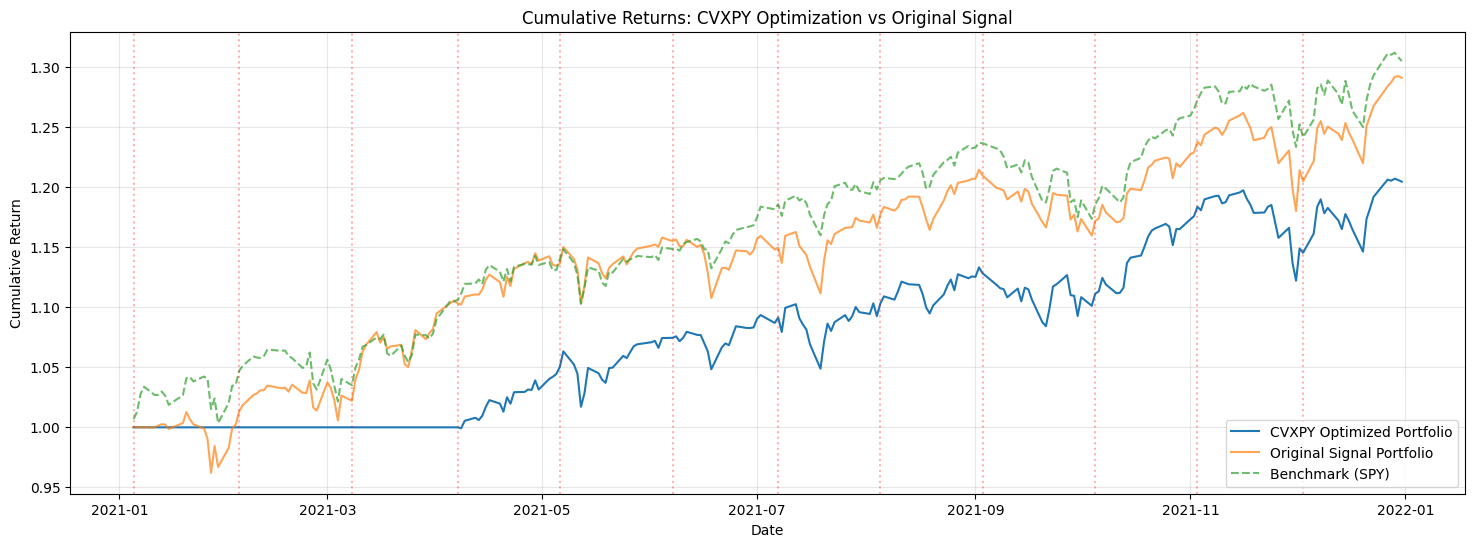

,Total Return (%),Annualised Return (%),Annualised Volatility (%),Annualised Sharpe Ratio,Max Drawdown (%)
CVXPY Optimized,20.459019,19.383078,11.755470,1.648856,-6.290254
Original Signal,29.113781,26.723924,14.570481,1.834114,-6.486359
Benchmark,30.505435,27.578111,12.930958,2.132720,-5.114147


In [76]:
# Run the CVXPY optimization performance function
performance_metrics = cvxpy_optimisation_performance(stock_returns, benchmark_ret)
performance_metrics